### PREPROCESSING

IMPORTS

In [1]:
#!pip install
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import DBSCAN
from matplotlib.lines import Line2D
import pyproj


READ CSV

In [2]:
df = pd.read_csv('C:/Users/sergi/OneDrive/Escritorio/Proyectos/Proyecto eb2/Locationdistance_clean_1.csv')

DATA TYPES AND NA'S

In [3]:
print(df.dtypes)
print( "\n")
print(df.isna().sum())

date_time             object
service                int64
user                   int64
user_uid               int64
user_time_zone       float64
app_raw_latitude     float64
app_raw_timestamp     object
app_raw_accuracy     float64
app_raw_longitude    float64
app_raw_distance     float64
app_raw_altitude     float64
app_raw_speed        float64
dtype: object


date_time                 0
service                   0
user                      0
user_uid                  0
user_time_zone            0
app_raw_latitude     690125
app_raw_timestamp         0
app_raw_accuracy          0
app_raw_longitude    690125
app_raw_distance     691640
app_raw_altitude          0
app_raw_speed        690125
dtype: int64


In [4]:
print(df["user_uid"].loc[df.app_raw_latitude.isna() == True].unique())
print(df["user_uid"].loc[df.app_raw_longitude.isna() == True].unique())
print(df["user_uid"].loc[df.app_raw_distance.isna() == True].unique())
print(df["user_uid"].loc[df.app_raw_speed.isna() == True].unique())

[  22   31   33  120  530  611  688 1603 1725 1809 2305 2362 2371 2410
 2454 2609 2672 2769 2999 3196 3295 3638 3736 3871 3925 3953 3962 4000
 4241 4244 4406 4473 4593 4601 4688 5191 5252 5258 5287 5491 5536]
[  22   31   33  120  530  611  688 1603 1725 1809 2305 2362 2371 2410
 2454 2609 2672 2769 2999 3196 3295 3638 3736 3871 3925 3953 3962 4000
 4241 4244 4406 4473 4593 4601 4688 5191 5252 5258 5287 5491 5536]
[  22   31   33   41  120  158  242  530  611  654  688  925 1489 1491
 1603 1725 1798 1809 2194 2305 2362 2371 2410 2454 2456 2609 2672 2769
 2856 2999 3196 3295 3638 3736 3824 3871 3925 3953 3962 4000 4241 4244
 4406 4473 4593 4601 4688 5191 5252 5258 5287 5491 5536]
[  22   31   33  120  530  611  688 1603 1725 1809 2305 2362 2371 2410
 2454 2609 2672 2769 2999 3196 3295 3638 3736 3871 3925 3953 3962 4000
 4241 4244 4406 4473 4593 4601 4688 5191 5252 5258 5287 5491 5536]


 AQUÍ ELIMINO LOS USUARIOS PERO TENEMOS QUE DECIDIR QUE HACER CON LOS NA'S QUE RESTAN DESPUÉS DE LA INTERPOLACIÓN

 ELIMINANDO USUARIOS PERDEMOS APROX 2 MILLONES DE LÍNEAS DE INFORMACIÓN

In [5]:
df = df[~df['user_uid'].isin([22,   31,   33,  120 , 530 , 611 , 688 ,1603 ,1725 ,1809 ,2305, 2362, 2371 ,2410
 ,2454 ,2609 ,2672, 2769 ,2999 ,3196, 3295, 3638 ,3736 ,3871, 3925 ,3953 ,3962 ,4000,
 4241, 4244, 4406 ,4473, 4593 ,4601 ,4688 ,5191, 5252, 5258, 5287, 5491 ,5536 ,41 , 158 , 242 , 654 , 925 ,1489 ,1491 ,1798, 2194, 2456 ,2856, 3824])]

In [6]:
print(df.isna().sum())

date_time            0
service              0
user                 0
user_uid             0
user_time_zone       0
app_raw_latitude     0
app_raw_timestamp    0
app_raw_accuracy     0
app_raw_longitude    0
app_raw_distance     0
app_raw_altitude     0
app_raw_speed        0
dtype: int64


### Data Features Check

Date Check

In [7]:
df['date_time'] = pd.to_datetime(df['date_time'])
df['app_raw_timestamp'] = pd.to_datetime(df['app_raw_timestamp'], format='ISO8601')

date_dismatch = df[df['date_time'] != df['app_raw_timestamp'].dt.date]

if len(date_dismatch) == 0:
    print('Date type features are correct!')
else:
    print('Oh oh, something is wrong with dates')
    print(f'Number of wrong lines: {len(date_dismatch)}')
    print(date_dismatch.head())

Date type features are correct!


Accuracy Check

In [8]:
accuracy_dismatch = df[(df['app_raw_accuracy'] > 100) & (df['app_raw_accuracy'] < 0)]
if len(accuracy_dismatch) == 0:
    print('Accuracy type features are correct!')
else:
    print('Oh oh, something is wrong with accuracys')
    print(f'Number of wrong lines: {len(date_dismatch)}')
    print(accuracy_dismatch.head())

Accuracy type features are correct!


Latitude and Longitude 

In [9]:
no_geo_info = df[(df['app_raw_latitude'] == -1.00000) & 
                 (df['app_raw_longitude'] == -1.00000) & 
                 (df['app_raw_accuracy'] == 0)]

if len(no_geo_info) == 0:
    print('There are not precision errors!')
else:
    print('Oh oh, something is wrong with coordinates')
    print(f'Number of wrong lines: {len(no_geo_info)}')
    print(no_geo_info.head())

There are not precision errors!


In [10]:
print(df.app_raw_latitude.describe())
print('\n')

min_latitude = df['app_raw_latitude'].min()
max_latitude = df['app_raw_latitude'].max()
print(f"Rango de latitudes: {min_latitude} a {max_latitude}")
print('\n')

print(df.app_raw_longitude.describe())
print('\n')

min_longitude = df['app_raw_longitude'].min()
max_longitude = df['app_raw_longitude'].max()
print(f"Rango de longitudes: {min_longitude} a {max_longitude}")

count    5.484904e+06
mean     5.279324e+00
std      1.425861e+01
min     -4.325587e+01
25%     -1.129461e-03
50%      4.470308e-05
75%      3.298912e-02
max      8.022546e+01
Name: app_raw_latitude, dtype: float64


Rango de latitudes: -43.2558708856 a 80.22545623779297


count    5.484904e+06
mean    -7.242000e-02
std      3.328655e+00
min     -6.349829e+01
25%     -1.199768e-02
50%     -6.872815e-06
75%      6.605206e-03
max      8.302552e+01
Name: app_raw_longitude, dtype: float64


Rango de longitudes: -63.49828720092773 a 83.02552032470703


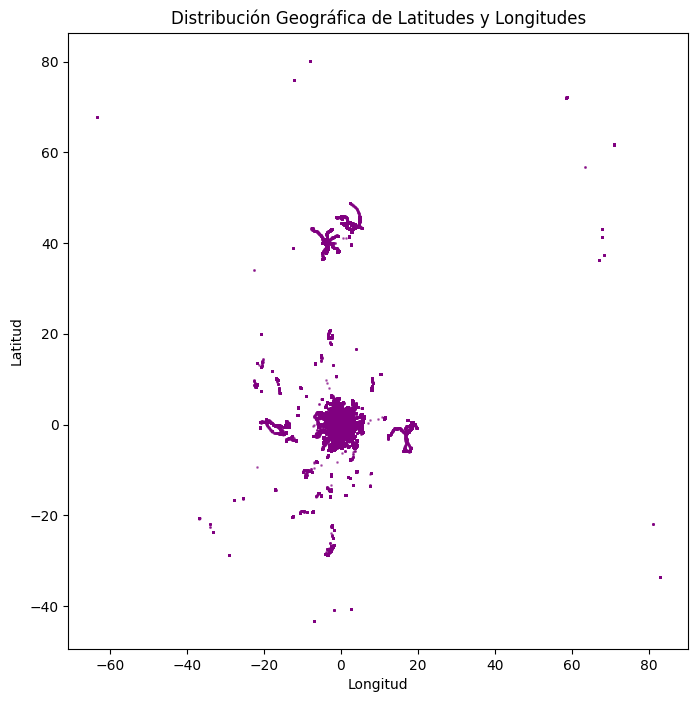

In [11]:
plt.figure(figsize=(8, 8))
plt.scatter(df['app_raw_longitude'], df['app_raw_latitude'], s=1, alpha=0.5, color='purple')
plt.title('Distribución Geográfica de Latitudes y Longitudes')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.show()

### Localizaciones Únicas

In [12]:
df_filtered = df[df['app_raw_accuracy'] >= 30]  
df_filtered = df_filtered.drop(['service', 'user'], axis=1)

In [13]:
# Crear el transformador una vez
transformer = pyproj.Transformer.from_crs("epsg:4326", "epsg:3857", always_xy=True)

# Extraer las columnas de longitud y latitud
longitudes = df_filtered['app_raw_longitude'].values
latitudes = df_filtered['app_raw_latitude'].values

# Aplicar la transformación vectorizada
x_metros, y_metros = transformer.transform(longitudes, latitudes)

# Agregar las nuevas columnas al DataFrame
df_filtered['x_metros'] = x_metros
df_filtered['y_metros'] = y_metros


In [14]:
grouped = df_filtered.groupby(['user_uid', 'date_time'])

def cluster_user_day(group):
    group = group.copy()
    coords = group[['x_metros', 'y_metros']].values
    
    epsilon = 100
    
    # Aplicar DBSCAN con la métrica 'haversine'
    db = DBSCAN(eps=epsilon, min_samples=2, metric='euclidean')
    cluster_labels = db.fit_predict(coords)
    
    group['cluster'] = cluster_labels
    return group

In [15]:
df_clustered = grouped.apply(cluster_user_day)
df_clustered.reset_index(drop=True, inplace=True)

C:\Users\sergi\AppData\Local\Temp\ipykernel_26388\4160530751.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_clustered = grouped.apply(cluster_user_day)


In [16]:
# Especificar el usuario y la fecha que deseas analizar
usuario_especifico = 14
fecha_especifica = pd.to_datetime('2018-12-23')

# Filtrar el DataFrame
df_usuario_fecha = df_clustered[
    (df_clustered['user_uid'] == usuario_especifico) &
    (df_clustered['date_time'] == fecha_especifica)  &
    (df_clustered['cluster'] != -1)
].copy()

num_clusters = df_usuario_fecha['cluster'].nunique()
print(f"Número total de clusters: {num_clusters}")



Número total de clusters: 3


In [17]:
# Ordenar el DataFrame por timestamp para asegurar la secuencia temporal
df_usuario_fecha = df_usuario_fecha.sort_values('app_raw_timestamp').reset_index(drop=True)

# Identificar cambios de cluster
df_usuario_fecha['cluster_prev'] = df_usuario_fecha['cluster'].shift()
df_usuario_fecha['cluster_change'] = df_usuario_fecha['cluster'] != df_usuario_fecha['cluster_prev']

# Crear un identificador de periodo para cada estancia en un cluster
df_usuario_fecha['period_id'] = df_usuario_fecha['cluster_change'].cumsum()

# Obtener la entrada y salida de cada periodo
periods = df_usuario_fecha.groupby('period_id').agg({
    'cluster': 'first',
    'app_raw_timestamp': 'first'
}).rename(columns={'app_raw_timestamp': 'entry_time'}).reset_index(drop=True)

# Añadir 'exit_time' como la 'entry_time' del siguiente periodo
periods['exit_time'] = periods['entry_time'].shift(-1)

# Para el último periodo, la salida es el último timestamp del DataFrame
last_exit_time = df_usuario_fecha['app_raw_timestamp'].iloc[-1]
periods.loc[periods.index[-1], 'exit_time'] = last_exit_time

# Calcular duración y acumular franjas horarias y tiempos por cluster
cluster_intervals = {}
cluster_total_time = {}

for idx, row in periods.iterrows():
    cluster = row['cluster']
    entry_time = row['entry_time']
    exit_time = row['exit_time']
    duration = (exit_time - entry_time).total_seconds()
    
    # Agregar duración al tiempo total por cluster
    cluster_total_time[cluster] = cluster_total_time.get(cluster, 0) + duration
    
    # Crear intervalo de tiempo
    interval = f"{entry_time.strftime('%H:%M')} - {exit_time.strftime('%H:%M')}"
    # Agregar intervalo a las franjas horarias del cluster
    if cluster in cluster_intervals:
        cluster_intervals[cluster].append(interval)
    else:
        cluster_intervals[cluster] = [interval]

# Convertir tiempo total a horas
for cluster in cluster_total_time:
    cluster_total_time[cluster] /= 3600  # De segundos a horas

# Calcular centroides
centroides = df_usuario_fecha.groupby('cluster')[['x_metros', 'y_metros']].mean().reset_index()

# Añadir 'tiempo_total' y 'franja_horaria' a los centroides
centroides['tiempo_total'] = centroides['cluster'].map(cluster_total_time)
centroides['franja_horaria'] = centroides['cluster'].map(lambda x: ', '.join(cluster_intervals[x]))

# Obtener la secuencia de clusters visitados
secuencia_clusters = periods['cluster'].tolist()

# Mostrar resultados
print("Centroides, tiempo total, y franja horaria de cada cluster:")
print(centroides)
print("\nSecuencia de clusters visitados:", secuencia_clusters)



Centroides, tiempo total, y franja horaria de cada cluster:
   cluster     x_metros     y_metros  tiempo_total  \
0        0  5178.811421 -5123.679394     10.841389   
1        1   -26.393162     0.878767      9.535556   
2        2  -555.542257 -2004.340404      3.202778   

                 franja_horaria  
0  00:06 - 08:22, 21:06 - 23:41  
1  08:22 - 16:52, 20:04 - 21:06  
2                 16:52 - 20:04  

Secuencia de clusters visitados: [0, 1, 2, 1, 0]


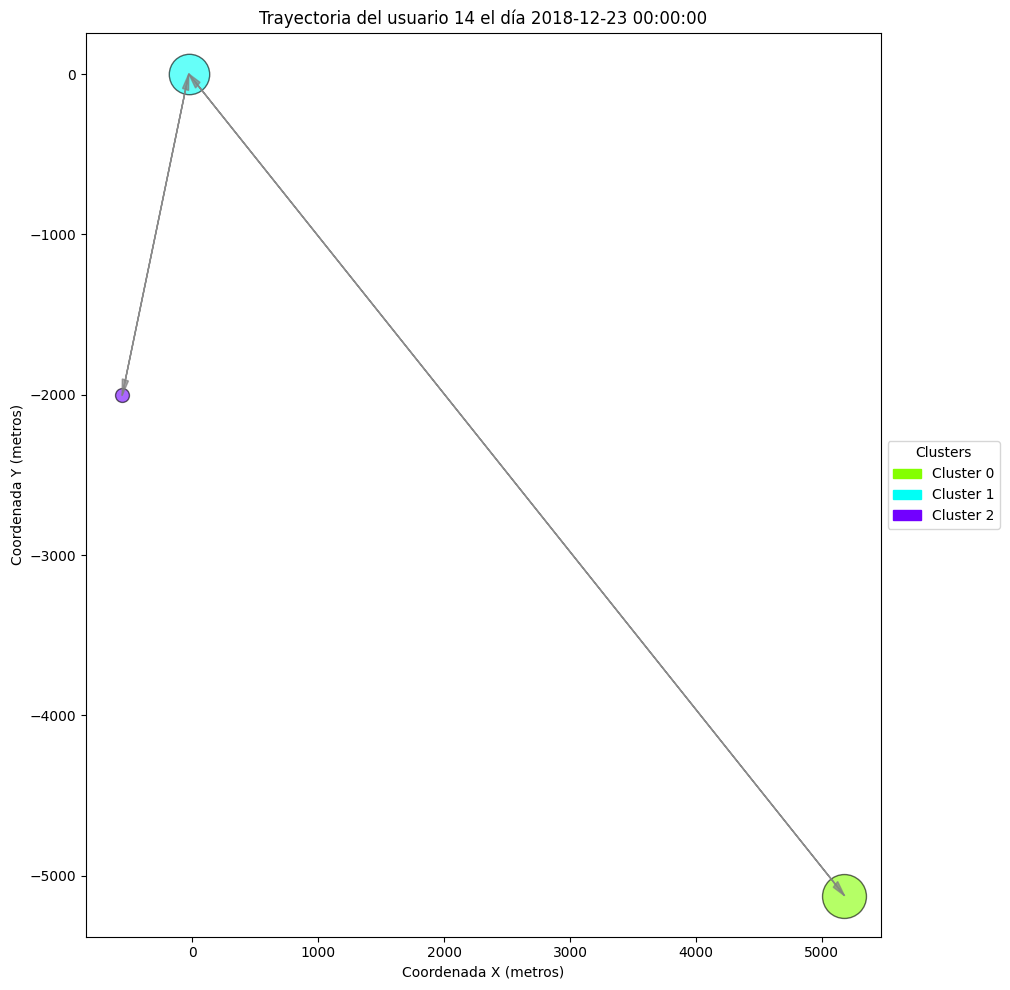

In [18]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np

# Verificar si hay más de un cluster
num_clusters = len(centroides)
tamaño_min, tamaño_max = 100, 1000

if num_clusters > 1:
    # Normalizar los tamaños de los círculos
    centroides['tamaño_circulo'] = (
        (centroides['tiempo_total'] - centroides['tiempo_total'].min()) /
        (centroides['tiempo_total'].max() - centroides['tiempo_total'].min())
    ) * (tamaño_max - tamaño_min) + tamaño_min
else:
    # Asignar un tamaño fijo si solo hay un cluster
    centroides['tamaño_circulo'] = (tamaño_max + tamaño_min) / 2

# Crear una paleta de colores y un diccionario de colores para cada cluster
palette = sns.color_palette('hsv', max(num_clusters, 1))
cluster_colors = dict(zip(centroides['cluster'], palette))

# Crear la figura para la visualización
plt.figure(figsize=(12, 10))

# Graficar los clusters como círculos
legend_handles = {}
for _, row in centroides.iterrows():
    cluster = row['cluster']
    plt.scatter(row['x_metros'], row['y_metros'], s=row['tamaño_circulo'],
                color=cluster_colors[cluster], alpha=0.6, edgecolors='k')
    # Añadir a la leyenda si no está ya
    if cluster not in legend_handles:
        legend_handles[cluster] = mpatches.Patch(color=cluster_colors[cluster], label=f'Cluster {int(cluster)}')

# Dibujar flechas para indicar la secuencia de movimiento entre clusters (si hay más de uno)
if len(secuencia_clusters) > 1:
    for i in range(len(secuencia_clusters) - 1):
        origen = centroides.loc[centroides['cluster'] == secuencia_clusters[i], ['x_metros', 'y_metros']].values[0]
        destino = centroides.loc[centroides['cluster'] == secuencia_clusters[i + 1], ['x_metros', 'y_metros']].values[0]
        plt.arrow(origen[0], origen[1], destino[0] - origen[0], destino[1] - origen[1],
                  length_includes_head=True, head_width=50, head_length=100, fc='gray', ec='gray', alpha=0.7)

# Configurar título, etiquetas y leyenda
plt.title(f"Trayectoria del usuario {usuario_especifico} el día {fecha_especifica}")
plt.xlabel('Coordenada X (metros)')
plt.ylabel('Coordenada Y (metros)')

# Solo mostrar la leyenda si hay clusters
if len(legend_handles) > 0:
    plt.legend(handles=legend_handles.values(), loc='center left', bbox_to_anchor=(1, 0.5), title="Clusters")

# Ajustar el layout para dar espacio a la leyenda y mostrar el gráfico
if len(legend_handles) > 0:
    plt.tight_layout(rect=[0, 0, 0.85, 1])
else:
    plt.tight_layout()

plt.show()


### CASA Y TRABAJO


In [ ]:
# Definir las horas correspondientes a casa y trabajo
from datetime import time

# Horas nocturnas para casa (por ejemplo, de 21:00 a 7:00)
hora_inicio_casa = time(21, 0)
hora_fin_casa = time(7, 0)

# Horas laborales para trabajo (por ejemplo, de 9:00 a 18:00)
hora_inicio_trabajo = time(9, 0)
hora_fin_trabajo = time(18, 0)

# Inicializar diccionarios para acumular tiempos en casa y trabajo por cluster
tiempo_casa_por_cluster = {}
tiempo_trabajo_por_cluster = {}

# Función para calcular el tiempo en segundos dentro de un periodo específico
def calcular_tiempo_en_periodo(entry_time, exit_time, inicio_periodo, fin_periodo):
    # Si el periodo cruza la medianoche
    cruzo_medianoche = inicio_periodo > fin_periodo

    total_time = 0
    current_time = entry_time

    while current_time < exit_time:
        hora_actual = current_time.time()
        dentro_periodo = False

        if cruzo_medianoche:
            if hora_actual >= inicio_periodo or hora_actual <= fin_periodo:
                dentro_periodo = True
        else:
            if inicio_periodo <= hora_actual <= fin_periodo:
                dentro_periodo = True

        if dentro_periodo:
            # Avanzar al siguiente minuto o hasta exit_time
            next_time = min(current_time + pd.Timedelta(minutes=1), exit_time)
            delta = (next_time - current_time).total_seconds()
            total_time += delta
            current_time = next_time
        else:
            # Avanzar al siguiente minuto
            current_time += pd.Timedelta(minutes=1)
            if current_time > exit_time:
                break

    return total_time

# Calcular tiempo en casa y trabajo para cada periodo
for idx, row in periods.iterrows():
    cluster = row['cluster']
    entry_time = row['entry_time']
    exit_time = row['exit_time']

    # Calcular tiempo en casa
    tiempo_casa = calcular_tiempo_en_periodo(entry_time, exit_time, hora_inicio_casa, hora_fin_casa)
    tiempo_casa_por_cluster[cluster] = tiempo_casa_por_cluster.get(cluster, 0) + tiempo_casa

    # Calcular tiempo en trabajo
    tiempo_trabajo = calcular_tiempo_en_periodo(entry_time, exit_time, hora_inicio_trabajo, hora_fin_trabajo)
    tiempo_trabajo_por_cluster[cluster] = tiempo_trabajo_por_cluster.get(cluster, 0) + tiempo_trabajo

# Convertir tiempos a horas
for cluster in tiempo_casa_por_cluster:
    tiempo_casa_por_cluster[cluster] /= 3600  # De segundos a horas

for cluster in tiempo_trabajo_por_cluster:
    tiempo_trabajo_por_cluster[cluster] /= 3600  # De segundos a horas

# Identificar el cluster de casa y trabajo
clusters_existentes = list(tiempo_casa_por_cluster.keys())

if len(clusters_existentes) == 1:
    cluster_unico = clusters_existentes[0]
    tiempo_casa = tiempo_casa_por_cluster[cluster_unico]
    tiempo_trabajo = tiempo_trabajo_por_cluster[cluster_unico]

    if tiempo_casa > tiempo_trabajo:
        cluster_casa = cluster_unico
        cluster_trabajo = None
    else:
        cluster_casa = None
        cluster_trabajo = cluster_unico
else:
    cluster_casa = max(tiempo_casa_por_cluster, key=tiempo_casa_por_cluster.get)
    # Excluir el cluster identificado como casa al buscar el de trabajo
    tiempo_trabajo_por_cluster_sin_casa = {k: v for k, v in tiempo_trabajo_por_cluster.items() if k != cluster_casa}
    if tiempo_trabajo_por_cluster_sin_casa:
        cluster_trabajo = max(tiempo_trabajo_por_cluster_sin_casa, key=tiempo_trabajo_por_cluster_sin_casa.get)
    else:
        cluster_trabajo = None  # No hay otro cluster que pueda ser trabajo

print(f"Cluster identificado como CASA: {cluster_casa}")
print(f"Tiempo en casa por cluster: {tiempo_casa_por_cluster}")

print(f"Cluster identificado como TRABAJO: {cluster_trabajo}")
print(f"Tiempo en trabajo por cluster: {tiempo_trabajo_por_cluster}")

# Añadir etiquetas de 'Casa' y 'Trabajo' al DataFrame de centroides
centroides['tipo'] = ''
if cluster_casa is not None:
    centroides.loc[centroides['cluster'] == cluster_casa, 'tipo'] = 'Casa'
if cluster_trabajo is not None:
    centroides.loc[centroides['cluster'] == cluster_trabajo, 'tipo'] = 'Trabajo'


Cluster identificado como CASA: 0
Tiempo en casa por cluster: {0: 9.481666666666667, 1: 0.10833333333333334, 2: 0.0}
Cluster identificado como TRABAJO: 1
Tiempo en trabajo por cluster: {0: 0.0, 1: 7.860555555555556, 2: 1.1333333333333333}


In [ ]:
import math

if cluster_casa is not None and cluster_trabajo is not None:
    # Obtener las coordenadas de casa y trabajo
    centroide_casa = centroides[centroides['cluster'] == cluster_casa][['x_metros', 'y_metros']].iloc[0]
    centroide_trabajo = centroides[centroides['cluster'] == cluster_trabajo][['x_metros', 'y_metros']].iloc[0]
    
    # Calcular la distancia euclidiana entre casa y trabajo
    distancia = math.sqrt((centroide_trabajo['x_metros'] - centroide_casa['x_metros'])**2 +
                          (centroide_trabajo['y_metros'] - centroide_casa['y_metros'])**2)
    
    print(f"La distancia entre casa y trabajo es de {distancia:.2f} metros.")
else:
    print("No es posible calcular la distancia entre casa y trabajo porque solo se identificó un cluster.")


La distancia entre casa y trabajo es de 7304.47 metros.


### ÍNDICE DE MOVILIDAD


In [ ]:
# Obtener combinaciones únicas de usuario y fecha
combinaciones_usuario_fecha = df_clustered[['user_uid', 'date_time']].drop_duplicates()

# Lista para almacenar las métricas de todos los usuarios y días
metricas_globales = []

# Iterar sobre cada combinación de usuario y fecha
for _, row in combinaciones_usuario_fecha.iterrows():
    usuario = row['user_uid']
    fecha = row['date_time']
    df_usuario_fecha = df_clustered[
        (df_clustered['user_uid'] == usuario) &
        (df_clustered['date_time'] == fecha) &
        (df_clustered['cluster'] != -1)  # Excluir ruido
    ]

    if df_usuario_fecha.empty:
        continue

    # Ordenar por timestamp
    df_usuario_fecha = df_usuario_fecha.sort_values('app_raw_timestamp').reset_index(drop=True)

    # Calcular distancias entre puntos consecutivos
    x_metros = df_usuario_fecha['x_metros'].values
    y_metros = df_usuario_fecha['y_metros'].values
    x_metros_prev = np.roll(x_metros, 1)  # Shift manual
    y_metros_prev = np.roll(y_metros, 1)

    distancias = np.sqrt((x_metros - x_metros_prev)**2 + (y_metros - y_metros_prev)**2)
    distancias[0] = 0  # La primera distancia es 0 porque no tiene anterior

    # Distancia total recorrida
    distancia_total = np.sum(distancias)

    # Número de localizaciones únicas visitadas
    num_localizaciones_unicas = df_usuario_fecha['cluster'].nunique()

    # Calcular diferencias de tiempo entre registros consecutivos
    tiempos = df_usuario_fecha['app_raw_timestamp'].values
    tiempos_prev = np.roll(tiempos, 1)  # Shift manual
    tiempo_diferencias = (tiempos - tiempos_prev) / np.timedelta64(1, 's')  # En segundos
    tiempo_diferencias[0] = 0  # El primer tiempo es 0 porque no tiene anterior

    # Identificar cambios de localización
    clusters = df_usuario_fecha['cluster'].values
    clusters_prev = np.roll(clusters, 1)
    cambios_localizacion = clusters != clusters_prev
    cambios_localizacion[0] = False  # El primer cambio es falso porque no tiene anterior

    # Calcular tiempo en movimiento (asumimos que hay movimiento en los cambios de localización)
    tiempo_en_movimiento = np.sum(tiempo_diferencias[cambios_localizacion])

    # Tiempo total
    tiempo_total = np.sum(tiempo_diferencias)

    # Tiempo en reposo
    tiempo_en_reposo = tiempo_total - tiempo_en_movimiento

    # Calcular velocidades
    velocidades = np.zeros_like(distancias)  # Inicializar velocidades con ceros

    # Solo calcular velocidades donde tiempo_diferencias > 0
    valores_validos = tiempo_diferencias > 0
    velocidades[valores_validos] = distancias[valores_validos] / tiempo_diferencias[valores_validos]

    # Manejar valores NaN o infinitos si aparecen (aunque no deberían con este enfoque)
    velocidades = np.nan_to_num(velocidades, nan=0)

    # Velocidad promedio
    velocidad_promedio = np.mean(velocidades)

    # Frecuencia de cambios de localización
    frecuencia_cambios = np.sum(cambios_localizacion)

    # Añadir las métricas al listado global
    metricas_globales.append({
        'user_uid': usuario,
        'date_time': fecha,
        'distancia_total': distancia_total,
        'num_localizaciones_unicas': num_localizaciones_unicas,
        'tiempo_en_movimiento': tiempo_en_movimiento,
        'tiempo_en_reposo': tiempo_en_reposo,
        'velocidad_promedio': velocidad_promedio,
        'frecuencia_cambios': frecuencia_cambios
    })

# Convertir las métricas globales a un DataFrame
df_metricas_globales = pd.DataFrame(metricas_globales)

# Mostrar el resultado
print(df_metricas_globales.head())

   user_uid  date_time  distancia_total  num_localizaciones_unicas  \
0        14 2018-12-20      2650.382071                          2   
1        14 2018-12-21        67.660041                          1   
2        14 2018-12-22     15371.134992                          2   
3        14 2018-12-23     19124.590215                          3   
4        14 2018-12-24       161.066187                          1   

   tiempo_en_movimiento  tiempo_en_reposo  velocidad_promedio  \
0               23401.0           22743.0            0.011600   
1                   0.0            9505.0            0.005933   
2               16175.0           68281.0            0.131149   
3               31673.0           53214.0            0.136681   
4                   0.0           57471.0            0.002745   

   frecuencia_cambios  
0                   1  
1                   0  
2                   2  
3                   4  
4                   0  


In [ ]:
media_distancia = df_metricas_globales['distancia_total'].mean()
std_distancia = df_metricas_globales['distancia_total'].std()

media_localizaciones = df_metricas_globales['num_localizaciones_unicas'].mean()
std_localizaciones = df_metricas_globales['num_localizaciones_unicas'].std()

media_tiempo_movimiento = df_metricas_globales['tiempo_en_movimiento'].mean()
std_tiempo_movimiento = df_metricas_globales['tiempo_en_movimiento'].std()

media_velocidad = df_metricas_globales['velocidad_promedio'].mean()
std_velocidad = df_metricas_globales['velocidad_promedio'].std()

media_cambios = df_metricas_globales['frecuencia_cambios'].mean()
std_cambios = df_metricas_globales['frecuencia_cambios'].std()


In [ ]:
# Evitar divisiones por cero en caso de desviación estándar cero
std_distancia = std_distancia if std_distancia != 0 else 1
std_localizaciones = std_localizaciones if std_localizaciones != 0 else 1
std_tiempo_movimiento = std_tiempo_movimiento if std_tiempo_movimiento != 0 else 1
std_velocidad = std_velocidad if std_velocidad != 0 else 1
std_cambios = std_cambios if std_cambios != 0 else 1

# Calcular z-scores para cada métrica en todo el DataFrame
df_metricas_globales['distancia_z'] = (df_metricas_globales['distancia_total'] - media_distancia) / std_distancia
df_metricas_globales['localizaciones_z'] = (df_metricas_globales['num_localizaciones_unicas'] - media_localizaciones) / std_localizaciones
df_metricas_globales['tiempo_movimiento_z'] = (df_metricas_globales['tiempo_en_movimiento'] - media_tiempo_movimiento) / std_tiempo_movimiento
df_metricas_globales['velocidad_z'] = (df_metricas_globales['velocidad_promedio'] - media_velocidad) / std_velocidad
df_metricas_globales['cambios_z'] = (df_metricas_globales['frecuencia_cambios'] - media_cambios) / std_cambios


In [ ]:
# Definir pesos para cada métrica (suma total de pesos = 1)
peso_distancia = 0.3
peso_localizaciones = 0.1
peso_tiempo_movimiento = 0.3
peso_velocidad = 0.1
peso_cambios = 0.2

# Calcular el índice de movilidad para cada fila
df_metricas_globales['indice_movilidad'] = (
    df_metricas_globales['distancia_z'] * peso_distancia +
    df_metricas_globales['localizaciones_z'] * peso_localizaciones +
    df_metricas_globales['tiempo_movimiento_z'] * peso_tiempo_movimiento +
    df_metricas_globales['velocidad_z'] * peso_velocidad +
    df_metricas_globales['cambios_z'] * peso_cambios
)


In [ ]:
usuarios_alta_movilidad = df_metricas_globales[df_metricas_globales['indice_movilidad'] > df_metricas_globales['indice_movilidad'].quantile(0.75)]
usuarios_baja_movilidad = df_metricas_globales[df_metricas_globales['indice_movilidad'] < df_metricas_globales['indice_movilidad'].quantile(0.25)]

print(usuarios_alta_movilidad.head())

    user_uid  date_time  distancia_total  num_localizaciones_unicas  \
3         14 2018-12-23     19124.590215                          3   
6         14 2018-12-26     11687.614894                          6   
17        14 2019-01-06    437162.158485                          4   
26        14 2019-01-17      2674.800421                          3   
27        14 2019-01-18     37303.064386                         10   

    tiempo_en_movimiento  tiempo_en_reposo  velocidad_promedio  \
3                31673.0           53214.0            0.136681   
6                64020.0           22022.0            0.182174   
17               15178.0           24231.0            0.446938   
26               40784.0           45277.0            0.031819   
27               17060.0           69199.0            0.206676   

    frecuencia_cambios  distancia_z  localizaciones_z  tiempo_movimiento_z  \
3                    4    -0.072057         -0.180157             1.234423   
6                   

In [ ]:
print(usuarios_baja_movilidad.head())

    user_uid  date_time  distancia_total  num_localizaciones_unicas  \
1         14 2018-12-21        67.660041                          1   
4         14 2018-12-24       161.066187                          1   
5         14 2018-12-25       697.800518                          1   
11        14 2018-12-31       420.475350                          1   
23        14 2019-01-14        22.360933                          1   

    tiempo_en_movimiento  tiempo_en_reposo  velocidad_promedio  \
1                    0.0            9505.0            0.005933   
4                    0.0           57471.0            0.002745   
5                    0.0           84526.0            0.011679   
11                   0.0           11412.0            0.036023   
23                   0.0             631.0            0.023636   

    frecuencia_cambios  distancia_z  localizaciones_z  tiempo_movimiento_z  \
1                    0    -0.148022         -0.758371            -0.812147   
4                   

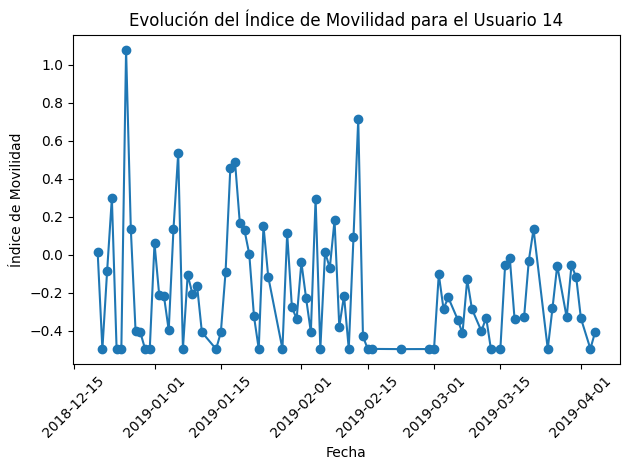

In [ ]:
usuario_especifico = 14  # Reemplaza con el ID del usuario que deseas analizar
df_usuario = df_metricas_globales[df_metricas_globales['user_uid'] == usuario_especifico]

plt.plot(df_usuario['date_time'], df_usuario['indice_movilidad'], marker='o')
plt.title(f'Evolución del Índice de Movilidad para el Usuario {usuario_especifico}')
plt.xlabel('Fecha')
plt.ylabel('Índice de Movilidad')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
